# 🤖 Machine Learning – Vorhersage des Energieverbrauchs

**Ziel:** Verschiedene Regressionsmodelle trainieren, vergleichen und ihre Vorhersagequalität bewerten.

In [236]:
#%pip install scikit-learn

In [237]:
# Bibliotheken importieren

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import mysql.connector

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [238]:
# Verbindung mit MySQL herstellen

connection = mysql.connector.connect(
    host="localhost",
    user="Dian-Data",
    password="dian_data_2026",
    database="ashrae_energy"
)

print("Verbindung erfolgreich")

Verbindung erfolgreich


In [239]:
# =================================================================
# Phase 35 – Reale ASHRAE-Daten für Machine Learning
# Zweck: Stromverbrauch (meter = 0)
# =================================================================

query_ml = """
SELECT
    `timestamp`,
    square_feet,
    year_built,
    floor_count,
    air_temperature,
    cloud_coverage,
    dew_temperature,
    precip_depth_1_hr,
    sea_level_pressure,
    wind_direction,
    wind_speed,
    meter,
    primary_use,
    meter_reading
FROM train_full
WHERE meter = 0
  AND air_temperature IS NOT NULL
  AND square_feet IS NOT NULL
  AND meter_reading IS NOT NULL
LIMIT 500000;
"""

df_ml = pd.read_sql(query_ml, connection)

print("Anzahl der Beobachtungen:", len(df_ml))
print("\nMeter-Werte:")
print(df_ml["meter"].value_counts())

print("\nStatistische Beschreibung:")
print(df_ml["meter_reading"].describe())

C:\Users\MamadouDianDiallo\AppData\Local\Temp\ipykernel_25744\1430434812.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ml = pd.read_sql(query_ml, connection)


Anzahl der Beobachtungen: 500000

Meter-Werte:
meter
0    500000
Name: count, dtype: int64

Statistische Beschreibung:
count    500000.000000
mean        245.893698
std         392.854375
min           0.000000
25%           0.000000
50%          83.135800
75%         331.383000
max        4521.000000
Name: meter_reading, dtype: float64


In [241]:
# =================================================================
# – Datenqualität und Verteilung
# Zweck: Überprüfung fehlender Werte und statistische Beschreibung
# =================================================================

print("Statistische Beschreibung des Stromverbrauchs")
print("---------------------------------------------")
print(df_ml["meter_reading"].describe())

print("\nFehlende Werte:")
print(df_ml.isnull().sum())

print("\nDatentypen:")
print(df_ml.dtypes)

Statistische Beschreibung des Stromverbrauchs
---------------------------------------------
count    500000.000000
mean        245.893698
std         392.854375
min           0.000000
25%           0.000000
50%          83.135800
75%         331.383000
max        4521.000000
Name: meter_reading, dtype: float64

Fehlende Werte:
timestamp                  0
square_feet                0
year_built                 0
floor_count           500000
air_temperature            0
cloud_coverage        218036
dew_temperature            0
precip_depth_1_hr         57
sea_level_pressure      4668
wind_direction         14220
wind_speed                 0
meter                      0
primary_use                0
meter_reading              0
dtype: int64

Datentypen:
timestamp             datetime64[us]
square_feet                    int64
year_built                     int64
floor_count                   object
air_temperature              float64
cloud_coverage               float64
dew_temperature  

In [242]:
#%pip install scikit-learn

In [243]:
# Datenaufbereitung

# Zielvariable
y = df_ml["meter_reading"]

# Eingangsvariablen
X = df_ml.drop(columns=["meter_reading"])

# Kategorische Variable umwandeln
X = pd.get_dummies(
    X,
    columns=["primary_use"],
    drop_first=True
)

# Fehlende Werte durch den Median ersetzen
X = X.fillna(X.median(numeric_only=True))

# Kontrolle
print("Anzahl der Merkmale:", X.shape[1])
print("Fehlende Werte nach der Aufbereitung:", X.isnull().sum().sum())

Anzahl der Merkmale: 18
Fehlende Werte nach der Aufbereitung: 500000


In [244]:
# Daten in Trainings- und Testdaten aufteilen

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Trainingsdaten:", len(X_train))
print("Testdaten:", len(X_test))

Trainingsdaten: 400000
Testdaten: 100000


In [245]:
# Datenaufbereitung

# Zielvariable
y = df_ml["meter_reading"]

# Eingangsvariablen
X = df_ml.drop(columns=["meter_reading"])

# Kategorische Variable umwandeln
X = pd.get_dummies(
    X,
    columns=["primary_use"],
    drop_first=True
)

# Fehlende Werte durch den Median ersetzen
X = X.fillna(X.median(numeric_only=True))

# Kontrolle
print("Anzahl der Merkmale:", X.shape[1])
print("Fehlende Werte nach der Aufbereitung:", X.isnull().sum().sum())

Anzahl der Merkmale: 18
Fehlende Werte nach der Aufbereitung: 500000


# 🌲 Random Forest – Nichtlineare Energieverbrauchsprognose

**Ziel:** Nichtlineare Zusammenhänge zwischen Gebäude-, Wetter- und Zeitmerkmalen und dem Energieverbrauch modellieren.

In [246]:
# =================================================================
# Phase 37 – Vorbereitung der Random-Forest-Daten
# Zweck: Daten laden, Feature Engineering und Imputation
# =================================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# ---------------------------------------------------------------
# 1. Feature-Daten laden, falls df_fe noch nicht existiert
# ---------------------------------------------------------------

if "df_fe" not in globals():

    query_features = """
    SELECT
        `timestamp`,
        square_feet,
        year_built,
        floor_count,
        air_temperature,
        dew_temperature,
        wind_speed,
        sea_level_pressure,
        meter_reading
    FROM train_full
    WHERE meter = 0
      AND square_feet IS NOT NULL
      AND meter_reading IS NOT NULL
    LIMIT 100000;
    """

    df_fe = pd.read_sql(
        query_features,
        connection
    )

    print("df_fe wurde aus MySQL geladen.")

else:

    print("df_fe ist bereits vorhanden.")

# ---------------------------------------------------------------
# 2. Arbeitskopie erstellen
# ---------------------------------------------------------------

df_rf = df_fe.copy()

# ---------------------------------------------------------------
# 3. Timestamp -> Zeitmerkmale
# ---------------------------------------------------------------

df_rf["timestamp"] = pd.to_datetime(
    df_rf["timestamp"],
    errors="coerce"
)

df_rf["hour"] = df_rf["timestamp"].dt.hour
df_rf["day_of_week"] = df_rf["timestamp"].dt.dayofweek
df_rf["month"] = df_rf["timestamp"].dt.month
df_rf["year"] = df_rf["timestamp"].dt.year

# ---------------------------------------------------------------
# 4. Features definieren
# ---------------------------------------------------------------

features_rf = [
    "square_feet",
    "year_built",
    "floor_count",
    "air_temperature",
    "dew_temperature",
    "wind_speed",
    "sea_level_pressure",
    "hour",
    "day_of_week",
    "month",
    "year"
]

target_rf = "meter_reading"

# ---------------------------------------------------------------
# 5. Daten für das Modell auswählen
# ---------------------------------------------------------------

df_model_rf = df_rf[
    features_rf + [target_rf]
].copy()

# ---------------------------------------------------------------
# 6. Numerische Konvertierung
# ---------------------------------------------------------------

for col in features_rf + [target_rf]:
    df_model_rf[col] = pd.to_numeric(
        df_model_rf[col],
        errors="coerce"
    )

# Zielvariable ohne Wert entfernen
df_model_rf = df_model_rf.dropna(
    subset=[target_rf]
).copy()

# ---------------------------------------------------------------
# 7. Vollständig leere Features erkennen
# ---------------------------------------------------------------

empty_features = [
    col
    for col in features_rf
    if df_model_rf[col].notna().sum() == 0
]

print("\nVollständig leere Features:")
print(empty_features)

# Nur nutzbare Features verwenden
features_valid = [
    col
    for col in features_rf
    if col not in empty_features
]

# ---------------------------------------------------------------
# 8. X und y
# ---------------------------------------------------------------

X_rf = df_model_rf[features_valid].copy()
y_rf = df_model_rf[target_rf].copy()

# ---------------------------------------------------------------
# 9. Train-Test-Split
# ---------------------------------------------------------------

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------------------
# 10. Fehlende Werte imputieren
# ---------------------------------------------------------------

imputer_rf = SimpleImputer(
    strategy="median"
)

X_train_imputed = imputer_rf.fit_transform(
    X_train_rf
)

X_test_imputed = imputer_rf.transform(
    X_test_rf
)

X_train_rf = pd.DataFrame(
    X_train_imputed,
    columns=features_valid,
    index=X_train_rf.index
)

X_test_rf = pd.DataFrame(
    X_test_imputed,
    columns=features_valid,
    index=X_test_rf.index
)

# ---------------------------------------------------------------
# 11. Kontrolle
# ---------------------------------------------------------------

print("\nRandom-Forest-Daten erfolgreich vorbereitet.")
print("---------------------------------------------")
print("Gesamtdaten :", len(df_model_rf))
print("Training    :", len(X_train_rf))
print("Test        :", len(X_test_rf))
print("Features    :", len(features_valid))

print("\nFeatures:")
print(features_valid)

print("\nFehlende Werte nach Imputation:")
print("Training:", X_train_rf.isna().sum().sum())
print("Test    :", X_test_rf.isna().sum().sum())

df_fe ist bereits vorhanden.

Vollständig leere Features:
['floor_count']

Random-Forest-Daten erfolgreich vorbereitet.
---------------------------------------------
Gesamtdaten : 100000
Training    : 80000
Test        : 20000
Features    : 10

Features:
['square_feet', 'year_built', 'air_temperature', 'dew_temperature', 'wind_speed', 'sea_level_pressure', 'hour', 'day_of_week', 'month', 'year']

Fehlende Werte nach Imputation:
Training: 0
Test    : 0


In [247]:
# =================================================================
# Phase 38 – Random Forest
# =================================================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_rf,
    y_train_rf
)

y_pred_rf = rf_model.predict(
    X_test_rf
)

print("Random Forest erfolgreich trainiert.")
print(
    "y_pred_rf existe :",
    "y_pred_rf" in globals()
)

Random Forest erfolgreich trainiert.
y_pred_rf existe : True


In [248]:
# =================================================================
# Phase 39 – Evaluation des Random-Forest-Modells
# =================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(
    y_test_rf,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test_rf,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test_rf,
    y_pred_rf
)

print("Random Forest – Modellbewertung")
print("--------------------------------")
print(f"MAE : {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²  : {r2_rf:.4f}")

Random Forest – Modellbewertung
--------------------------------
MAE : 21.51
RMSE: 75.06
R²  : 0.9773


In [249]:
# =================================================================
# Phase 35.1 – Vergleich der Regressionsmodelle
# Zweck: Vergleich von Originalskala und Log-Transformation
# =================================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------------------
# 1. Daten vorbereiten
# ---------------------------------------------------------------

features = ["air_temperature", "square_feet"]
target = "meter_reading"

X = df_ml[features].copy()
y = df_ml[target].copy()

# Kontrolle
print("Fehlende Werte vor der Aufbereitung:")
print(X.isnull().sum())

# Zielvariable prüfen
if y.isnull().any():
    raise ValueError("Die Zielvariable meter_reading enthält fehlende Werte.")

# ---------------------------------------------------------------
# 2. Train-Test-Split
# ---------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------------------
# 3. Fehlende Werte behandeln
#    Keine Spalten und keine Zeilen werden entfernt
# ---------------------------------------------------------------

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=features,
    index=X_train.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=features,
    index=X_test.index
)

print("\nFehlende Werte nach der Aufbereitung:")
print("X_train:", X_train.isnull().sum().sum())
print("X_test :", X_test.isnull().sum().sum())

# ---------------------------------------------------------------
# 4. Lineare Regression – Originalskala
# ---------------------------------------------------------------

modell_original = LinearRegression()

modell_original.fit(
    X_train,
    y_train
)

y_pred_original = modell_original.predict(X_test)

mae_original = mean_absolute_error(
    y_test,
    y_pred_original
)

rmse_original = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_original
    )
)

r2_original = r2_score(
    y_test,
    y_pred_original
)

# ---------------------------------------------------------------
# 5. Log-transformierte Regression
# ---------------------------------------------------------------

y_train_log = np.log1p(y_train)

modell_log = LinearRegression()

modell_log.fit(
    X_train,
    y_train_log
)

y_pred_log = modell_log.predict(X_test)

# Rücktransformation
y_pred_log_original = np.expm1(y_pred_log)

mae_log = mean_absolute_error(
    y_test,
    y_pred_log_original
)

rmse_log = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_log_original
    )
)

r2_log = r2_score(
    y_test,
    y_pred_log_original
)

# ---------------------------------------------------------------
# 6. Vergleich
# ---------------------------------------------------------------

print("\nModellvergleich")
print("================")

print("\nLineare Regression – Originalskala")
print(f"MAE : {mae_original:.2f}")
print(f"RMSE: {rmse_original:.2f}")
print(f"R²  : {r2_original:.4f}")

print("\nLog-transformierte Regression")
print(f"MAE : {mae_log:.2f}")
print(f"RMSE: {rmse_log:.2f}")
print(f"R²  : {r2_log:.4f}")

Fehlende Werte vor der Aufbereitung:
air_temperature    0
square_feet        0
dtype: int64

Fehlende Werte nach der Aufbereitung:
X_train: 0
X_test : 0

Modellvergleich

Lineare Regression – Originalskala
MAE : 230.26
RMSE: 359.67
R²  : 0.1649

Log-transformierte Regression
MAE : 224.47
RMSE: 426.45
R²  : -0.1740


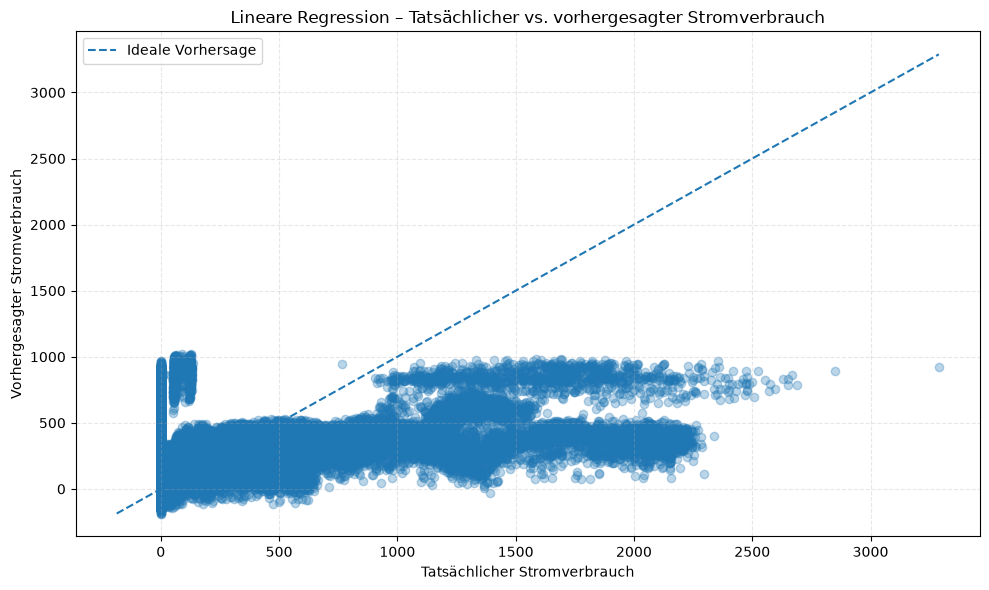

In [250]:
# =================================================================
# Phase 35.2 – Visualisierung: Lineare Regression
# Zweck: Tatsächliche vs. vorhergesagte Werte
# =================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_original,
    alpha=0.3
)

# Ideale Vorhersage: y = x
min_value = min(
    y_test.min(),
    y_pred_original.min()
)

max_value = max(
    y_test.max(),
    y_pred_original.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1.5,
    label="Ideale Vorhersage"
)

plt.xlabel("Tatsächlicher Stromverbrauch")
plt.ylabel("Vorhergesagter Stromverbrauch")
plt.title(
    "Lineare Regression – Tatsächlicher vs. vorhergesagter Stromverbrauch"
)

plt.legend()
plt.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

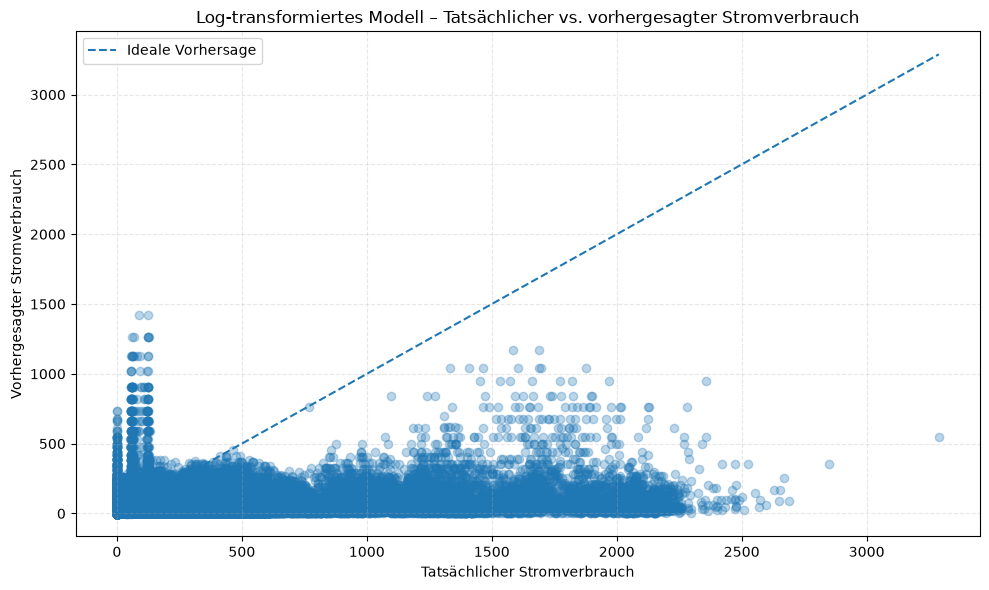

In [251]:
# =================================================================
# Phase 35.4 – Visualisierung: Log-transformiertes Modell
# Zweck: Tatsächliche vs. vorhergesagte Werte
# =================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_log_original,
    alpha=0.3
)

# Ideale Vorhersage
min_value = min(
    y_test.min(),
    y_pred_log_original.min()
)

max_value = max(
    y_test.max(),
    y_pred_log_original.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=1.5,
    label="Ideale Vorhersage"
)

plt.xlabel("Tatsächlicher Stromverbrauch")
plt.ylabel("Vorhergesagter Stromverbrauch")
plt.title(
    "Log-transformiertes Modell – Tatsächlicher vs. vorhergesagter Stromverbrauch"
)

plt.legend()
plt.grid(linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Tatsächliche Werte : 20000
Vorhersagen        : 20000


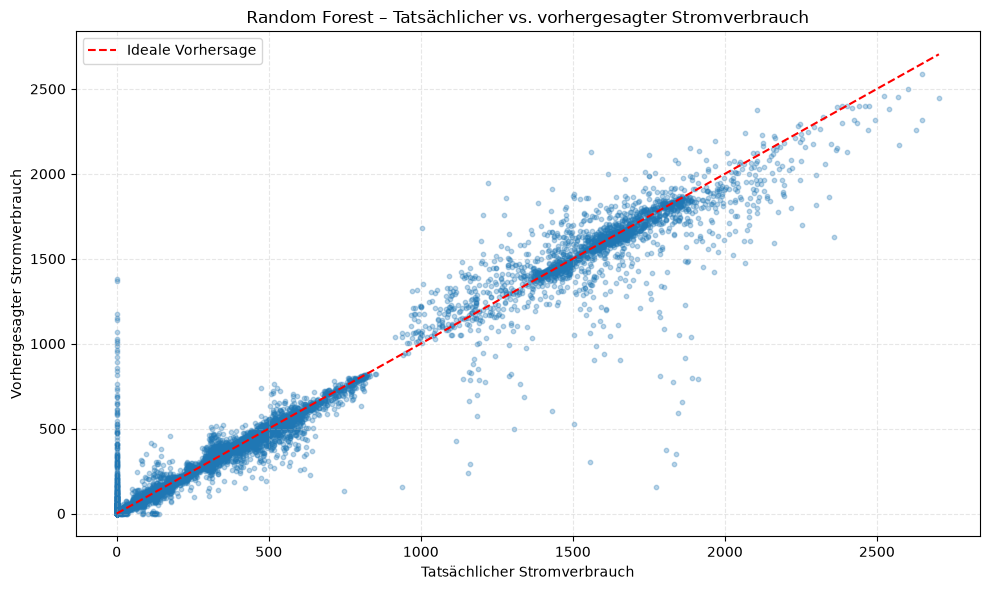

In [252]:
# =================================================================
# Phase 40 – Visualisierung: Random Forest
# Zweck: Tatsächliche vs. vorhergesagte Werte
# =================================================================

import matplotlib.pyplot as plt

# Vérification des dimensions
print("Tatsächliche Werte :", len(y_test_rf))
print("Vorhersagen        :", len(y_pred_rf))

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test_rf,
    y_pred_rf,
    alpha=0.3,
    s=10
)

# Ideale Vorhersage
min_value = min(
    y_test_rf.min(),
    y_pred_rf.min()
)

max_value = max(
    y_test_rf.max(),
    y_pred_rf.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Ideale Vorhersage"
)

plt.xlabel("Tatsächlicher Stromverbrauch")
plt.ylabel("Vorhergesagter Stromverbrauch")

plt.title(
    "Random Forest – Tatsächlicher vs. vorhergesagter Stromverbrauch"
)

plt.legend()
plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [253]:
print("y_pred_rf existe :", "y_pred_rf" in globals())

y_pred_rf existe : True


In [254]:
print("y_pred_original existe :", "y_pred_original" in globals())

y_pred_original existe : True


In [255]:
# =================================================================
# Phase 35.4 – Interpretation
# Zweck: Vergleich und Interpretation der Machine-Learning-Modelle
#
# Modelle:
# 1. Lineare Regression          -> y_pred_original
# 2. Log-transformiertes Modell  -> y_pred_log_original
# 3. Random Forest               -> y_pred_rf
#
# Referenzen:
# Phase 35.1 – Lineare Regression und Log-Transformation
# Phase 35.2 – Visualisierung des Log-Modells
# Phase 35.5 – Random Forest
# =================================================================

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("--- Interpretation des Machine-Learning-Modells ---")
print()

# ================================================================
# 1. Lineare Regression – Originalskala
# ================================================================

print("Phase 35.1 – Lineare Regression")
print(f"MAE : {mae_original:.2f}")
print(f"RMSE: {rmse_original:.2f}")
print(f"R²  : {r2_original:.4f}")

# ================================================================
# 2. Log-transformierte Regression
# ================================================================

print()
print("Log-transformierte Regression")
print(f"MAE : {mae_log:.2f}")
print(f"RMSE: {rmse_log:.2f}")
print(f"R²  : {r2_log:.4f}")

# ================================================================
# 3. Random Forest
# ================================================================

mae_rf = mean_absolute_error(
    y_test_rf,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test_rf,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test_rf,
    y_pred_rf
)

print()
print("3. Random Forest")
print("----------------")
print(f"MAE : {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²  : {r2_rf:.4f}")


# ================================================================
# 4. Vergleich der drei Modelle
# ================================================================

print()
print("--- Modellvergleich ---")

rmse_values = {
    "Lineare Regression": rmse_original,
    "Log-transformierte Regression": rmse_log,
    "Random Forest": rmse_rf
}

best_model = min(
    rmse_values,
    key=rmse_values.get
)

print(
    f"Nach dem RMSE erreicht '{best_model}' "
    f"den niedrigsten Fehler."
)

# Vergleich Lineare Regression / Log-Modell
if rmse_log < rmse_original:
    print(
        "Die Log-Transformation reduziert den RMSE "
        "gegenüber der Originalskala."
    )
elif rmse_log > rmse_original:
    print(
        "Die Log-Transformation reduziert den RMSE "
        "gegenüber der Originalskala nicht."
    )
else:
    print(
        "Beide linearen Modelle erreichen denselben RMSE."
    )

# ================================================================
# 5. Datenverteilung
# ================================================================

print()
print("--- Datenverteilung ---")

print(
    "Die Verbrauchsdaten weisen eine asymmetrische Verteilung auf."
)

print(
    "Deshalb wurde zusätzlich eine Log-Transformation getestet."
)

# ================================================================
# 6. Verwendete Variablen
# ================================================================

print()
print("--- Verwendete Variablen ---")

print(
    "Die ersten Modelle verwenden air_temperature und square_feet "
    "als Eingangsvariablen."
)

print(
    "Diese beiden Variablen allein erklären den Energieverbrauch "
    "nur begrenzt."
)

# ================================================================
# 7. Visualisierung
# ================================================================

print()
print("--- Visualisierung ---")

print(
    "Die Vorhersage-Diagramme zeigen die Abweichungen zwischen "
    "tatsächlichen und vorhergesagten Verbrauchswerten."
)

print(
    "Bei höheren Verbrauchswerten treten teilweise deutliche "
    "Abweichungen von der idealen Vorhersagelinie auf."
)

# ================================================================
# 8. Fazit
# ================================================================

print()
print("--- Fazit ---")

print(
    "Die linearen Modelle mit air_temperature und square_feet "
    "zeigen eine begrenzte Vorhersagequalität."
)

print(
    "Der Random Forest verwendet zusätzliche Gebäude-, Wetter- "
    "und Zeitmerkmale und erreicht auf seinem Testdatensatz "
    "deutlich bessere Modellkennzahlen."
)

print(
    "Für einen direkten und fairen Vergleich sollten alle drei "
    "Modelle jedoch auf demselben Train-Test-Split bewertet werden."
)

--- Interpretation des Machine-Learning-Modells ---

Phase 35.1 – Lineare Regression
MAE : 230.26
RMSE: 359.67
R²  : 0.1649

Log-transformierte Regression
MAE : 224.47
RMSE: 426.45
R²  : -0.1740

3. Random Forest
----------------
MAE : 21.51
RMSE: 75.06
R²  : 0.9773

--- Modellvergleich ---
Nach dem RMSE erreicht 'Random Forest' den niedrigsten Fehler.
Die Log-Transformation reduziert den RMSE gegenüber der Originalskala nicht.

--- Datenverteilung ---
Die Verbrauchsdaten weisen eine asymmetrische Verteilung auf.
Deshalb wurde zusätzlich eine Log-Transformation getestet.

--- Verwendete Variablen ---
Die ersten Modelle verwenden air_temperature und square_feet als Eingangsvariablen.
Diese beiden Variablen allein erklären den Energieverbrauch nur begrenzt.

--- Visualisierung ---
Die Vorhersage-Diagramme zeigen die Abweichungen zwischen tatsächlichen und vorhergesagten Verbrauchswerten.
Bei höheren Verbrauchswerten treten teilweise deutliche Abweichungen von der idealen Vorhersagelinie 

# ⚙️ Feature Engineering – Vorbereitung der ML-Merkmale

**Ziel:** Zeit-, Gebäude- und Wettermerkmale für die Machine-Learning-Modelle aufbereiten.

In [256]:
# =================================================================
# Phase 36 – Feature Engineering
# Zweck: Erweiterung der Eingangsvariablen
# =================================================================

import pandas as pd
import numpy as np

query_features = """
SELECT
    `timestamp`,
    square_feet,
    year_built,
    floor_count,
    air_temperature,
    dew_temperature,
    wind_speed,
    sea_level_pressure,
    meter_reading
FROM train_full
WHERE meter = 0
  AND square_feet IS NOT NULL
  AND meter_reading IS NOT NULL
LIMIT 100000;
"""

df_fe = pd.read_sql(query_features, connection)

print("Anzahl Datensätze:", len(df_fe))
display(df_fe.head())

C:\Users\MamadouDianDiallo\AppData\Local\Temp\ipykernel_25744\313443998.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_fe = pd.read_sql(query_features, connection)


Anzahl Datensätze: 100000


,timestamp,square_feet,year_built,floor_count,air_temperature,dew_temperature,wind_speed,sea_level_pressure,meter_reading
0,2016-01-01 00:00:00,7432,2008,None,25.0,20.0,0.0,1019.7,0.0
1,2016-01-01 01:00:00,7432,2008,None,24.4,21.1,1.5,1020.2,0.0
2,2016-01-01 02:00:00,7432,2008,None,22.8,21.1,0.0,1020.2,0.0
3,2016-01-01 03:00:00,7432,2008,None,21.1,20.6,0.0,1020.1,0.0
4,2016-01-01 04:00:00,7432,2008,None,20.0,20.0,2.6,1020.0,0.0


In [257]:
# =================================================================
# Phase 36.2 – Zeitbasierte Merkmale
# =================================================================

df_fe["timestamp"] = pd.to_datetime(df_fe["timestamp"])

# Zeitmerkmale erstellen
df_fe["hour"] = df_fe["timestamp"].dt.hour
df_fe["day_of_week"] = df_fe["timestamp"].dt.dayofweek
df_fe["month"] = df_fe["timestamp"].dt.month
df_fe["is_weekend"] = (df_fe["day_of_week"] >= 5).astype(int)

print("Zeitmerkmale wurden erstellt.")

Zeitmerkmale wurden erstellt.


In [258]:
# =================================================================
# Phase 36.3 – Gebäudealter
# =================================================================

df_fe["building_age"] = (
    df_fe["timestamp"].dt.year - df_fe["year_built"]
)

# Unplausible Werte entfernen
df_fe.loc[df_fe["building_age"] < 0, "building_age"] = np.nan

print("Gebäudealter wurde berechnet.")

Gebäudealter wurde berechnet.


In [259]:
# =================================================================
# Phase 36.4 – Finale Features 
# =================================================================

features = [
    "air_temperature",
    "dew_temperature",
    "wind_speed",
    "sea_level_pressure",
    "square_feet",
    "building_age",
    "hour",
    "day_of_week",
    "month",
    "is_weekend"
]

target = "meter_reading"

# Fehlende Werte entfernen
df_model = df_fe[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

print("Anzahl Beobachtungen:", len(df_model))
print("Anzahl Features:", len(features))
print("Features:", features)
print("Part des données conservées :", round(len(df_model) / len(df_fe) * 100, 1), "%")

Anzahl Beobachtungen: 99008
Anzahl Features: 10
Features: ['air_temperature', 'dew_temperature', 'wind_speed', 'sea_level_pressure', 'square_feet', 'building_age', 'hour', 'day_of_week', 'month', 'is_weekend']
Part des données conservées : 99.0 %


In [260]:
# =================================================================
# Phase 37 – Random Forest
# Zweck: Nichtlineares Regressionsmodell
# =================================================================

features = [
    "air_temperature",
    "dew_temperature",
    "wind_speed",
    "sea_level_pressure",
    "square_feet",
    "building_age",
    "hour",
    "day_of_week",
    "month",
    "is_weekend"
]

target = "meter_reading"

df_model = df_fe[features + [target]].dropna()

X = df_model[features]
y = df_model[target]

print("Anzahl Beobachtungen:", len(df_model))
print("Part des données conservées :", round(len(df_model) / len(df_fe) * 100, 1), "%")

Anzahl Beobachtungen: 99008
Part des données conservées : 99.0 %


In [261]:
# =================================================================
# Phase 37 – Train-Test-Split
# Zweck: Einheitliche Datenbasis für alle Modelle
# =================================================================

features = ["air_temperature", "square_feet"]
target = "meter_reading"

# 500.000 reale Strommessungen verwenden
X = df_ml[features].copy()
y = df_ml[target].copy()

# Prüfen
print("Gesamte Beobachtungen:", len(X))

# Train-Test-Split: 80 % / 20 %
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Trainingsdaten:", len(X_train))
print("Testdaten:", len(X_test))

Gesamte Beobachtungen: 500000
Trainingsdaten: 400000
Testdaten: 100000


In [262]:
# Cellule 37.2
# Random-Forest-Modell erstellen
rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Modell trainieren
rf_model.fit(X_train, y_train)

# Vorhersagen
y_pred_rf = rf_model.predict(X_test)

print("Random-Forest-Modell wurde trainiert.")

Random-Forest-Modell wurde trainiert.


In [263]:
# =================================================================
# Phase 37.3 – Bewertung des Random-Forest-Modells
# =================================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("-------------")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R²  :", round(r2_rf, 4))

Random Forest
-------------
MAE : 151.0
RMSE: 259.05
R²  : 0.5668


In [ ]:
linear_model_fe = LinearRegression()
linear_model_fe.fit(X_train, y_train)

y_pred_linear_fe = linear_model_fe.predict(X_test)

mae_linear_fe = mean_absolute_error(y_test, y_pred_linear_fe)
rmse_linear_fe = np.sqrt(mean_squared_error(y_test, y_pred_linear_fe))
r2_linear_fe = r2_score(y_test, y_pred_linear_fe)

print("Régression linéaire ( gleiche Features)")
print("MAE :", round(mae_linear_fe, 2))
print("RMSE:", round(rmse_linear_fe, 2))
print("R²  :", round(r2_linear_fe, 4))

Régression linéaire (mêmes features)
MAE : 230.26
RMSE: 359.67
R²  : 0.1649


In [265]:
# =================================================================
# Phase 38 – Modellvergleich
# =================================================================

from sklearn.linear_model import LinearRegression

# Lineares Modell
linear_model_fe = LinearRegression()
linear_model_fe.fit(X_train, y_train)

y_pred_linear_fe = linear_model_fe.predict(X_test)

# Bewertung lineares Modell
mae_linear_fe = mean_absolute_error(y_test, y_pred_linear_fe)

rmse_linear_fe = np.sqrt(
    mean_squared_error(y_test, y_pred_linear_fe)
)

r2_linear_fe = r2_score(
    y_test,
    y_pred_linear_fe
)

In [266]:
# Ergebnisse vergleichen
comparison = pd.DataFrame({
    "Modell": [
        "Lineare Regression",
        "Random Forest"
    ],
    "MAE": [
        mae_linear_fe,
        mae_rf
    ],
    "RMSE": [
        rmse_linear_fe,
        rmse_rf
    ],
    "R²": [
        r2_linear_fe,
        r2_rf
    ]
})

comparison = comparison.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 4
})

display(comparison)

,Modell,MAE,RMSE,R²
0,Lineare Regression,230.26,359.67,0.1649
1,Random Forest,151.00,259.05,0.5668


In [267]:
# =================================================================
# Phase 39 – Fehleranalyse
# Zweck: Analyse der Vorhersagefehler
# =================================================================

residuals = y_test - y_pred_rf

print("Fehleranalyse – Random Forest")
print("------------------------------")
print("Mittlerer Fehler :", round(residuals.mean(), 2))
print("Mittlerer absoluter Fehler :", round(np.abs(residuals).mean(), 2))

Fehleranalyse – Random Forest
------------------------------
Mittlerer Fehler : -0.6
Mittlerer absoluter Fehler : 151.0


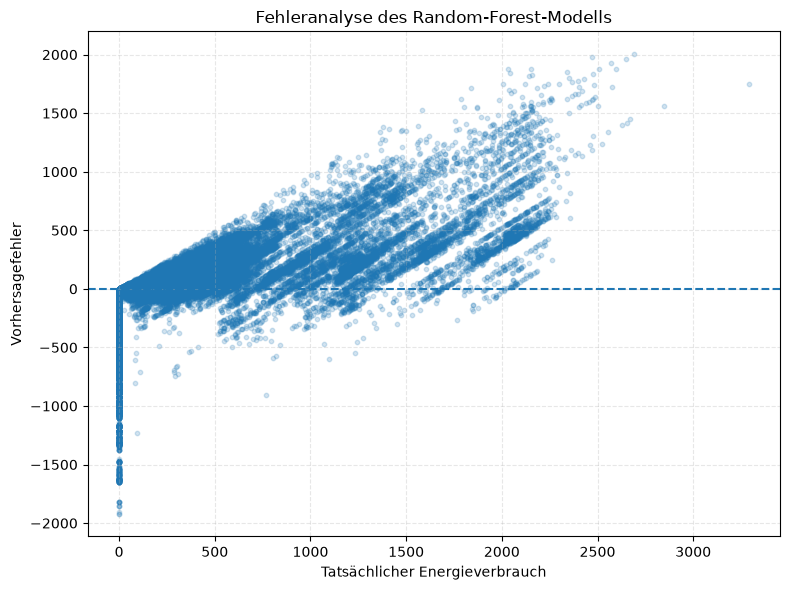

In [268]:
# ================================================================
# Zelle 39.2 – Visualisierung der Modellfehler
# ================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    residuals,
    alpha=0.2,
    s=10
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Tatsächlicher Energieverbrauch")
plt.ylabel("Vorhersagefehler")
plt.title("Fehleranalyse des Random-Forest-Modells")

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# 🚀 API – Bereitstellung des Machine-Learning-Modells
**Ziel:**  Das trainierte Modell über eine FastAPI-Schnittstelle für Vorhersagen bereitstellen.

In [269]:
# =================================================================
# Phase 37 – Training des Random-Forest-Modells
# =================================================================

rf_model.fit(
    X_train_rf,
    y_train_rf
)

print("Random-Forest-Modell erfolgreich trainiert.")

Random-Forest-Modell erfolgreich trainiert.


In [270]:
y_pred_rf = rf_model.predict(X_test_rf)

print("Vorhersagen erfolgreich erstellt.")

Vorhersagen erfolgreich erstellt.


In [271]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test_rf, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
r2_rf = r2_score(y_test_rf, y_pred_rf)

print("Random Forest")
print("-------------")
print(f"MAE : {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R²  : {r2_rf:.4f}")

Random Forest
-------------
MAE : 23.47
RMSE: 78.78
R²  : 0.9750


In [272]:
import joblib
from pathlib import Path

# Dossier API à la racine du projet
api_dir = Path("../05_API")

# Créer le dossier s'il n'existe pas
api_dir.mkdir(parents=True, exist_ok=True)

# Sauvegarder le modèle
model_path = api_dir / "rf_model.joblib"

joblib.dump(
    rf_model,
    model_path
)

print(f"Modèle sauvegardé dans : {model_path}")

Modèle sauvegardé dans : ..\05_API\rf_model.joblib


In [273]:
print(model_path.exists())

True


In [274]:
import joblib

rf_model = joblib.load("../05_API/rf_model.joblib")

print("Random-Forest-Modell erfolgreich geladen.")

Random-Forest-Modell erfolgreich geladen.


In [275]:
from pathlib import Path

model_path = Path("../05_API/rf_model.joblib")

print("Datei vorhanden:", model_path.exists())
print("Pfad:", model_path.resolve())

Datei vorhanden: True
Pfad: C:\Users\MamadouDianDiallo\Desktop\ASHRAE_Project\ASHRAE-Energy-Analysis\05_API\rf_model.joblib


In [281]:
import joblib
from pathlib import Path

model_path = Path("../05_API/rf_model.joblib")

rf_model = joblib.load(model_path)

print("Random-Forest-Modell erfolgreich geladen.")
print("Pfad:", model_path.resolve())

Random-Forest-Modell erfolgreich geladen.
Pfad: C:\Users\MamadouDianDiallo\Desktop\ASHRAE_Project\ASHRAE-Energy-Analysis\05_API\rf_model.joblib


In [277]:
print(model_path.exists())

True


In [282]:
# =================================================================
# Phase 37.6 – API: Pipeline Random Forest finale
# Zweck: Genau das aktuelle 10-Feature-Modell für die API speichern
# =================================================================

from pathlib import Path
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# ---------------------------------------------------------------
# 1. Projet racine
# ---------------------------------------------------------------

project_root = None

for path in [Path.cwd(), *Path.cwd().parents]:
    if path.name == "ASHRAE-Energy-Analysis":
        project_root = path
        break

if project_root is None:
    raise FileNotFoundError(
        "Projektordner 'ASHRAE-Energy-Analysis' nicht gefunden."
    )

api_dir = project_root / "05_API"
api_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------
# 2. Features définitives de l'API
# ---------------------------------------------------------------

features_api = [
    "square_feet",
    "year_built",
    "air_temperature",
    "dew_temperature",
    "wind_speed",
    "sea_level_pressure",
    "hour",
    "day_of_week",
    "month",
    "year"
]

target_api = "meter_reading"

# ---------------------------------------------------------------
# 3. Préparer les données
# ---------------------------------------------------------------

df_api = df_rf.copy()

df_api["timestamp"] = pd.to_datetime(
    df_api["timestamp"],
    errors="coerce"
)

df_api["hour"] = df_api["timestamp"].dt.hour
df_api["day_of_week"] = df_api["timestamp"].dt.dayofweek
df_api["month"] = df_api["timestamp"].dt.month
df_api["year"] = df_api["timestamp"].dt.year

# Conversion numérique
for col in features_api:
    df_api[col] = pd.to_numeric(
        df_api[col],
        errors="coerce"
    )

df_api[target_api] = pd.to_numeric(
    df_api[target_api],
    errors="coerce"
)

# Target obligatoire
df_api = df_api.dropna(
    subset=[target_api]
).copy()

# ---------------------------------------------------------------
# 4. X / y
# ---------------------------------------------------------------

X_api = df_api[features_api].copy()
y_api = df_api[target_api].copy()

# ---------------------------------------------------------------
# 5. Train / Test
# ---------------------------------------------------------------

X_train_api, X_test_api, y_train_api, y_test_api = train_test_split(
    X_api,
    y_api,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------------------
# 6. Pipeline = Imputer + Random Forest
# ---------------------------------------------------------------

rf_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

# Entraînement
rf_pipeline.fit(
    X_train_api,
    y_train_api
)

# ---------------------------------------------------------------
# 7. Vérifications
# ---------------------------------------------------------------

print("Anzahl Features:", rf_pipeline.n_features_in_)
print("Features:", features_api)

# ---------------------------------------------------------------
# 8. Sauvegarde dans le BON dossier
# ---------------------------------------------------------------

pipeline_path = api_dir / "rf_pipeline.joblib"

joblib.dump(
    rf_pipeline,
    pipeline_path
)

print()
print("Pipeline erfolgreich gespeichert.")
print("Datei:", pipeline_path)
print("Datei vorhanden:", pipeline_path.exists())

Anzahl Features: 10
Features: ['square_feet', 'year_built', 'air_temperature', 'dew_temperature', 'wind_speed', 'sea_level_pressure', 'hour', 'day_of_week', 'month', 'year']

Pipeline erfolgreich gespeichert.
Datei: c:\Users\MamadouDianDiallo\Desktop\ASHRAE_Project\ASHRAE-Energy-Analysis\05_API\rf_pipeline.joblib
Datei vorhanden: True
